# Eye Tracking Data Analysis Notebook



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

 Data Loading



In [6]:
filename = "data/subject-1.tsv"

# Load file
df = pd.read_csv(filename, sep="\t")

print(f"\nLoaded file: {filename}")
print("Original DataFrame head:")
display(df.head())



Loaded file: data/subject-1.tsv
Original DataFrame head:


,CNT,TIME,TIME_TICK,FPOGX,FPOGY,FPOGS,FPOGD,FPOGID,FPOGV,LPOGX,...,LPUPILV,REYEX,REYEY,REYEZ,RPUPILD,RPUPILV,CX,CY,CS,USER
0,136594,921.73505,2886586537937,0.48179,0.54035,921.35327,0.38177,1907,1,0.53955,...,1,0.02730,-0.01969,0.63555,0.00303,1,0.42227,0.47361,0,NaN
1,136595,921.74152,2886586602905,0.47024,0.59652,921.35327,0.38177,1907,0,0.49834,...,1,0.02730,-0.01969,0.63555,0.00259,1,0.42227,0.47361,0,START_TRIAL
2,136596,921.74841,2886586671727,0.36946,0.85952,921.35327,0.38177,1907,0,0.49834,...,1,-0.03279,-0.01995,0.66169,0.00396,1,0.42227,0.47361,0,NaN
3,136597,921.75476,2886586735200,0.35694,0.89973,921.35327,0.38177,1907,0,0.49834,...,1,-0.03279,-0.01995,0.66169,0.00382,1,0.42227,0.47361,0,IMAGE_START_F000.PNG
4,136598,921.76117,2886586799108,0.31570,1.03194,921.35327,0.38177,1907,0,0.49834,...,1,-0.03279,-0.01995,0.66169,0.00384,1,0.42227,0.47361,0,NaN


Basic Data Cleaning and Gaze Column Mapping



In [7]:
# Cleanup basic
df.replace(["NA", "undefined"], np.nan, inplace=True)

# Convert common numeric columns if present
numeric_cols = ["time_trial_loop", "count_trial_loop"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# gaze mapping

gaze_x_candidates = ["dx", "FPOGX", "BPOGX", "LPOGX", "RPOGX", "CX"]
gaze_y_candidates = ["dy", "FPOGY", "BPOGY", "LPOGY", "RPOGY", "CY"]

def pick_first_existing(cols):
    for c in cols:
        if c in df.columns:
            return c
    return None

gx = pick_first_existing(gaze_x_candidates)
gy = pick_first_existing(gaze_y_candidates)

if gx is None or gy is None:
    raise ValueError("No usable gaze columns found in dataset")

print(f"\nUsing gaze columns → X: {gx}, Y: {gy}")

df["dx"] = pd.to_numeric(df[gx], errors="coerce")
df["dy"] = pd.to_numeric(df[gy], errors="coerce")

# Drop invalid rows safely
df = df.dropna(subset=["dx", "dy"])

print("\nValid gaze rows after cleaning:", len(df))


Using gaze columns → X: FPOGX, Y: FPOGY

Valid gaze rows after cleaning: 7511


Gaze Velocity Calculation and Distribution



Calculated velocities for 7508 data points.


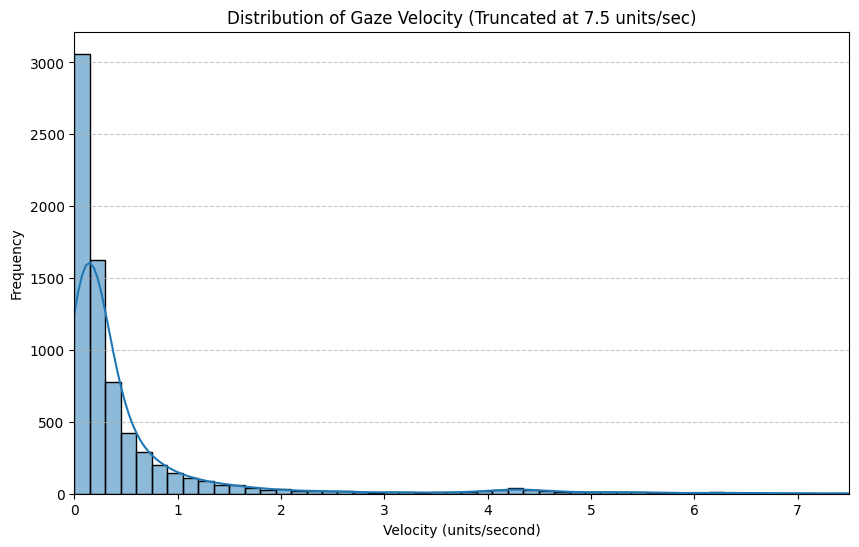


--- Gaze Velocity Statistics ---

count    7508.000000
mean        1.496045
std        10.380264
min         0.000000
25%         0.090076
50%         0.197385
75%         0.496338
max       300.779792
Name: velocity, dtype: float64


In [ ]:
df['TIME'] = pd.to_numeric(df['TIME'], errors='coerce')
df = df.sort_values(by='TIME').reset_index(drop=True)

# Calculate the change in gaze coordinates (pixels/units) and time
dx_diff = df['dx'].diff()
dy_diff = df['dy'].diff()
dt = df['TIME'].diff()

# Calculate instantaneous velocity (euclidean distance / time difference)
# Avoid division by zero for dt
df['velocity'] = np.sqrt(dx_diff**2 + dy_diff**2) / dt

# Remove potential infinite values (from dt=0) or NaNs (from diff() on first row)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna(subset=['velocity'])

print(f"Calculated velocities for {len(df)} data points.")

# Set a fixed maximum velocity for visualization
v_max = 7.5

# Plot the distribution of gaze velocities
plt.figure(figsize=(10, 6))
# Filter data for the plot up to 7.5 to avoid the extreme skew from tracker artifacts
sns.histplot(df[df['velocity'] <= v_max]['velocity'], bins=50, kde=True)
plt.title(f'Distribution of Gaze Velocity')
plt.xlabel('Velocity (units/second)')
plt.ylabel('Frequency')
plt.xlim(0, v_max)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Display basic statistics of velocity
print('\n--- Gaze Velocity Statistics ---\n')
print(df['velocity'].describe())


DataFrame Inspection



In [11]:
print("\n--- DataFrame Head ---\n")
display(df.head())
print("\n--- DataFrame Info ---\n")
df.info()


--- DataFrame Head ---



,CNT,TIME,TIME_TICK,FPOGX,FPOGY,FPOGS,FPOGD,FPOGID,FPOGV,LPOGX,...,REYEZ,RPUPILD,RPUPILV,CX,CY,CS,USER,dx,dy,velocity
1,136597,921.75476,2886586735200,0.35694,0.89973,921.35327,0.38177,1907,0,0.49834,...,0.66169,0.00382,1,0.42227,0.47361,0,IMAGE_START_F000.PNG,0.35694,0.89973,6.632136
2,136598,921.76117,2886586799108,0.31570,1.03194,921.35327,0.38177,1907,0,0.49834,...,0.66169,0.00384,1,0.42227,0.47361,0,NaN,0.31570,1.03194,21.605722
3,136599,921.76807,2886586868133,0.33155,1.00791,921.35327,0.38177,1907,0,0.49834,...,0.65345,0.00378,1,0.42227,0.47361,0,NaN,0.33155,1.00791,4.171959
4,136600,921.77509,2886586938081,0.34471,0.94691,921.35327,0.38177,1907,0,0.49834,...,0.65345,0.00399,1,0.42227,0.47361,0,NaN,0.34471,0.94691,8.889375
5,136601,921.78174,2886587005046,0.36480,0.84586,921.35327,0.38177,1907,0,0.49834,...,0.65345,0.00412,1,0.42227,0.47361,0,NaN,0.36480,0.84586,15.492890



--- DataFrame Info ---

<class 'pandas.DataFrame'>
RangeIndex: 7508 entries, 1 to 7508
Data columns (total 45 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CNT        7508 non-null   int64  
 1   TIME       7508 non-null   float64
 2   TIME_TICK  7508 non-null   int64  
 3   FPOGX      7508 non-null   float64
 4   FPOGY      7508 non-null   float64
 5   FPOGS      7508 non-null   float64
 6   FPOGD      7508 non-null   float64
 7   FPOGID     7508 non-null   int64  
 8   FPOGV      7508 non-null   int64  
 9   LPOGX      7508 non-null   float64
 10  LPOGY      7508 non-null   float64
 11  LPOGV      7508 non-null   int64  
 12  RPOGX      7508 non-null   float64
 13  RPOGY      7508 non-null   float64
 14  RPOGV      7508 non-null   int64  
 15  BPOGX      7508 non-null   float64
 16  BPOGY      7508 non-null   float64
 17  BPOGV      7508 non-null   int64  
 18  LPCX       7508 non-null   float64
 19  LPCY       7508 non-null   float64

In [12]:
print("\n--- Descriptive Statistics ---\n")
display(df.describe())


--- Descriptive Statistics ---



,CNT,TIME,TIME_TICK,FPOGX,FPOGY,FPOGS,FPOGD,FPOGID,FPOGV,LPOGX,...,REYEY,REYEZ,RPUPILD,RPUPILV,CX,CY,CS,dx,dy,velocity
count,7508.000000,7508.000000,7.508000e+03,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,...,7508.000000,7508.000000,7508.000000,7508.0,7.508000e+03,7.508000e+03,7508.0,7508.000000,7508.000000,7508.000000
mean,142360.776372,960.362492,2.886973e+12,0.496695,0.532103,960.129702,0.221154,2049.378796,0.837906,0.561923,...,-0.017870,0.647047,0.003599,1.0,4.222700e-01,4.736100e-01,0.0,0.496695,0.532103,1.496045
std,3341.959880,22.385409,2.238541e+08,0.177179,0.239529,22.366875,0.234935,78.978024,0.368561,0.136614,...,0.000748,0.013289,0.000310,0.0,5.551485e-17,1.110297e-16,0.0,0.177179,0.239529,10.380264
min,136597.000000,921.754760,2.886587e+12,-0.425650,-2.012820,921.353270,0.018250,1907.000000,0.000000,-0.425650,...,-0.021630,0.614950,0.001690,1.0,4.222700e-01,4.736100e-01,0.0,-0.425650,-2.012820,0.000000
25%,139372.750000,940.347888,2.886773e+12,0.452058,0.428085,940.175420,0.087040,1984.000000,1.000000,0.492780,...,-0.018330,0.638740,0.003500,1.0,4.222700e-01,4.736100e-01,0.0,0.452058,0.428085,0.090076
50%,142749.000000,962.962860,2.886999e+12,0.509205,0.522515,962.664945,0.148040,2059.500000,1.000000,0.569940,...,-0.017850,0.644430,0.003640,1.0,4.222700e-01,4.736100e-01,0.0,0.509205,0.522515,0.197385
75%,145229.250000,979.576357,2.887165e+12,0.626700,0.731670,979.467410,0.268490,2113.000000,1.000000,0.670588,...,-0.017350,0.658310,0.003760,1.0,4.222700e-01,4.736100e-01,0.0,0.626700,0.731670,0.496338
max,147708.000000,996.179380,2.887331e+12,0.771580,1.295900,995.623720,1.855160,2173.000000,1.000000,0.809180,...,-0.015410,0.699640,0.004390,1.0,4.222700e-01,4.736100e-01,0.0,0.771580,1.295900,300.779792


In [13]:
print("\n--- Missing Values Count Per Column ---\n")
display(df.isnull().sum().to_frame(name='Missing Values'))


--- Missing Values Count Per Column ---



,Missing Values
CNT,0
TIME,0
TIME_TICK,0
FPOGX,0
FPOGY,0
FPOGS,0
FPOGD,0
FPOGID,0
FPOGV,0
LPOGX,0


Visualizations



#### Time vs. Gaze Velocity Trace



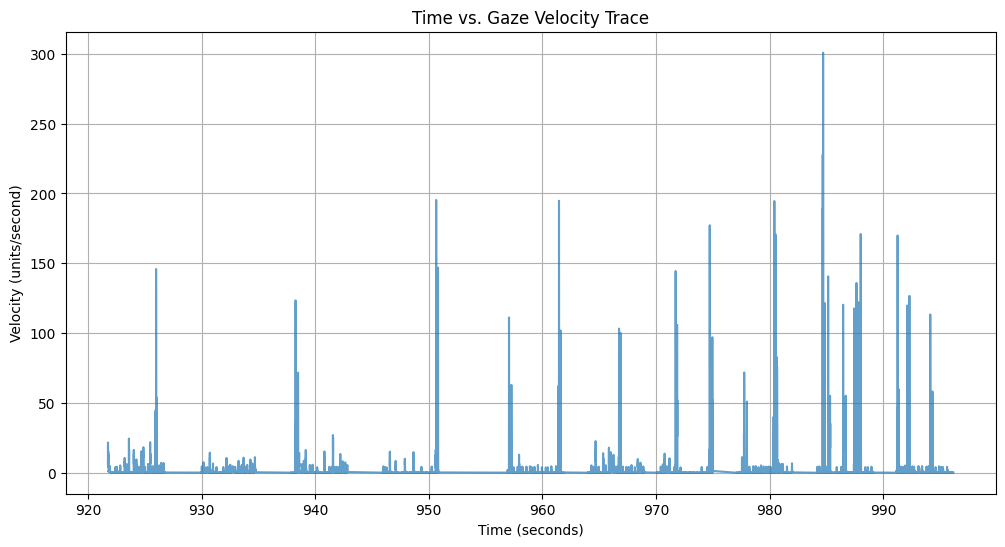

In [14]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='TIME', y='velocity', data=df, alpha=0.7)
plt.title('Time vs. Gaze Velocity Trace')
plt.xlabel('Time (seconds)')
plt.ylabel('Velocity (units/second)')
plt.grid(True)
plt.show()

#### Gaze Density Heatmap


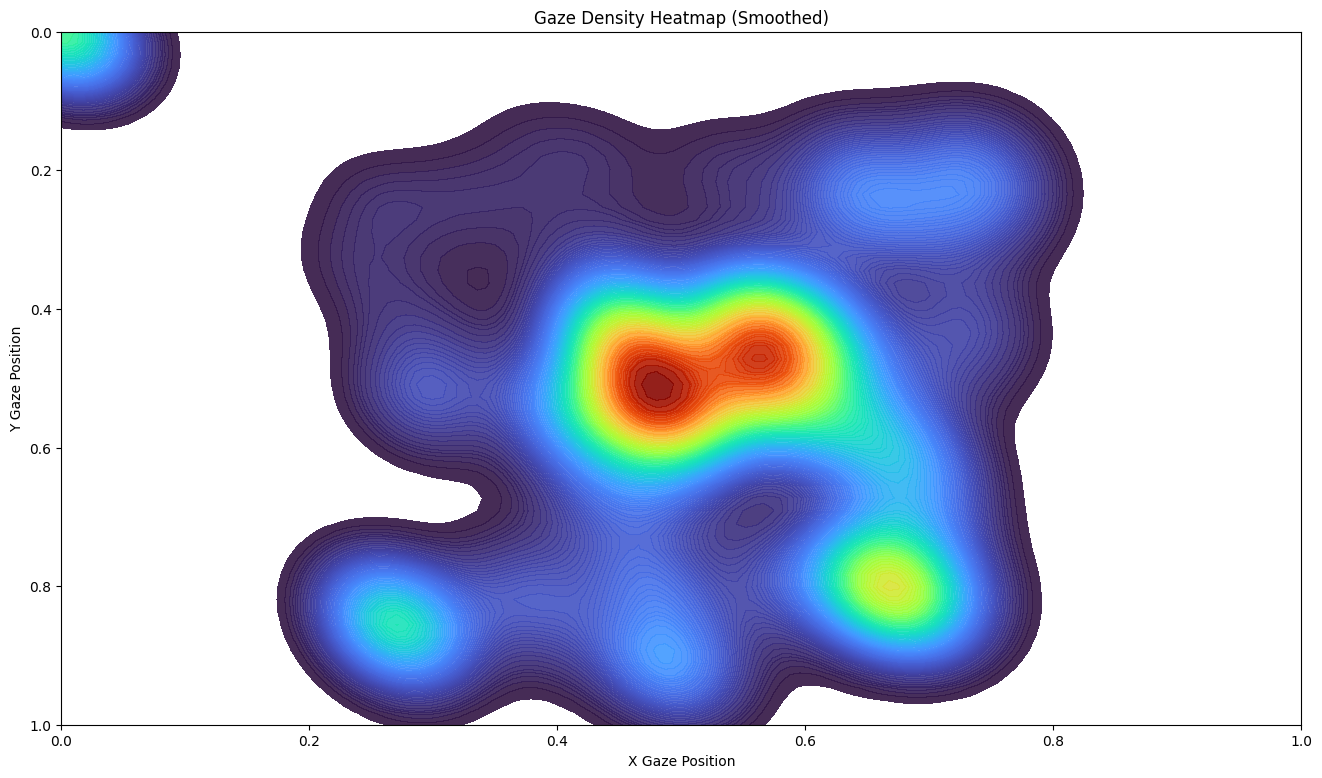

In [21]:
# Use a wide rectangle for the figure size (similar to a 16:9 monitor)
plt.figure(figsize=(16, 9))

# A Kernel Density Estimate (KDE) plot looks much more like a traditional eye-tracking heatmap
sns.kdeplot(
    x=df['dx'], 
    y=df['dy'], 
    cmap='turbo',       # 'turbo' or 'inferno' give a classic thermal heatmap look
    fill=True, 
    thresh=0.02,        # Threshold to remove background noise (hides the lowest 2% density)
    levels=100,         # High number of levels makes the gradient very smooth
    alpha=0.9
)

plt.title('Gaze Density Heatmap (Smoothed)')
plt.xlabel('X Gaze Position')
plt.ylabel('Y Gaze Position')

# Eye tracking coordinates usually have (0,0) at the top left and are normalized [0,1].
# Setting ylim from 1 to 0 naturally inverts the Y-axis so it matches the screen.
plt.xlim(0, 1)
plt.ylim(1, 0)

# We REMOVED the set_aspect('equal') line so it stretches to fill our 12x7 rectangle

plt.show()


#### Gaze Distribution (Scatter Plot)



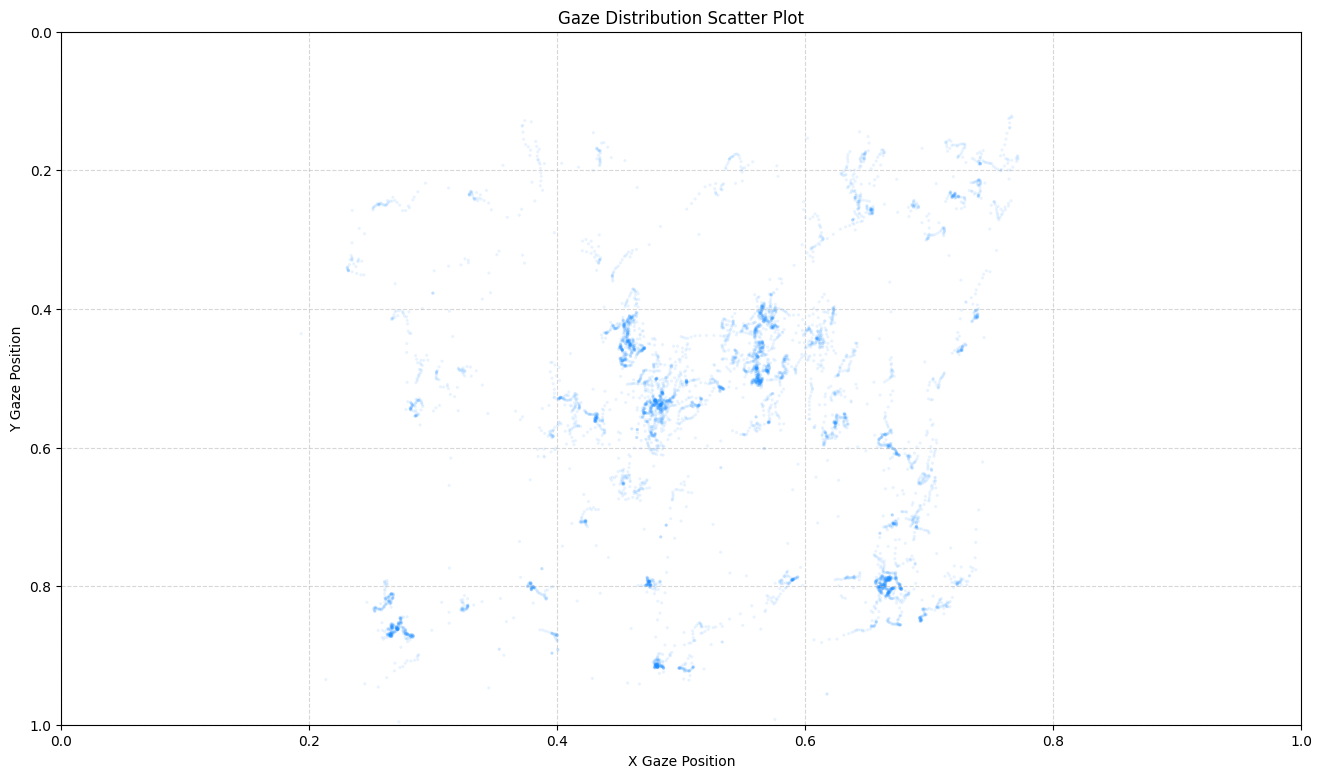

In [23]:
plt.figure(figsize=(16, 9))

# Use tiny markers (s=5) and high transparency (alpha=0.1) 
# so dense areas appear darker instead of becoming a single giant solid blob.
plt.scatter(df["dx"], df["dy"], alpha=0.1, s=5, c='dodgerblue', edgecolors='none')

plt.xlabel("X Gaze Position")
plt.ylabel("Y Gaze Position")
plt.title("Gaze Distribution Scatter Plot")

# Lock the axes to normalized screen bounds [0,1] and invert Y-axis to match the screen
plt.xlim(0, 1)
plt.ylim(1, 0)

# Soften the grid so it doesn't distract from the faint dots
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


#### Scanpath Plot



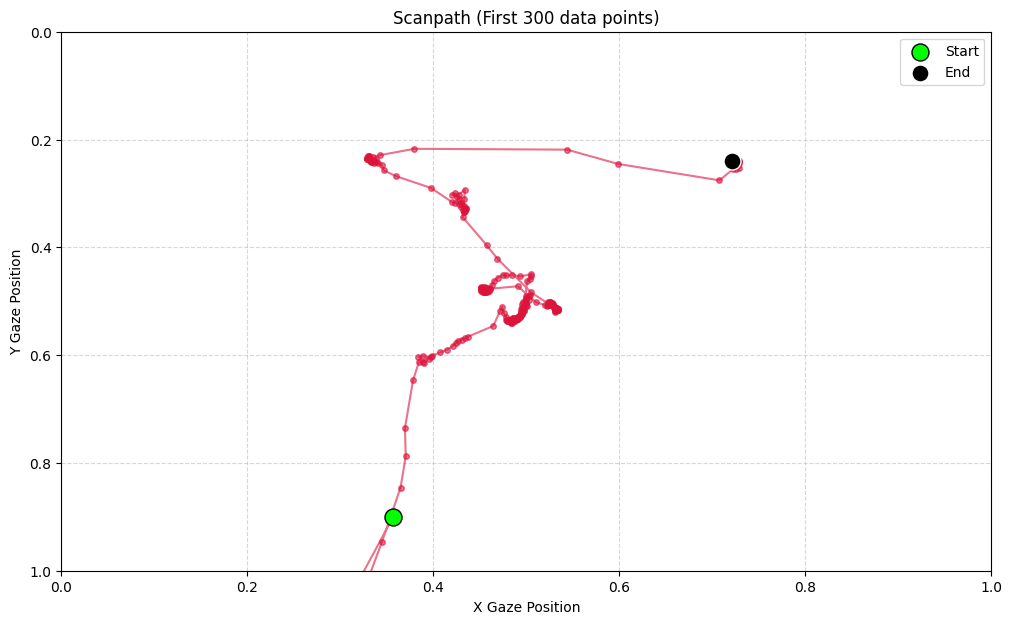

In [25]:
# A scanpath of 14,000+ points is unreadable.
# Let's take just the first 300 points (e.g., the first few seconds of viewing)
n_points = 300
df_slice = df.head(n_points)

plt.figure(figsize=(12, 7))

# Plot the scanpath for the sliced data
plt.plot(df_slice["dx"], df_slice["dy"], marker='o', markersize=4, linestyle='-', linewidth=1.5, alpha=0.6, color='crimson')

# Mark the very first and very last point so we can see the direction of the eye movement
plt.scatter(df_slice["dx"].iloc[0], df_slice["dy"].iloc[0], color='lime', s=150, zorder=5, edgecolors='black', label='Start')
plt.scatter(df_slice["dx"].iloc[-1], df_slice["dy"].iloc[-1], color='black', s=150, zorder=5, edgecolors='white', label='End')

plt.xlabel("X Gaze Position")
plt.ylabel("Y Gaze Position")
plt.title(f"Scanpath (First {n_points} data points)")

# Lock the axes to normalized screen bounds [0,1] and invert Y-axis to match the screen
plt.xlim(0, 1)
plt.ylim(1, 0)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Maximum Gaze Velocity Analysis



In [26]:
# Find the row with the maximum velocity
max_velocity_row = df.loc[df['velocity'].idxmax()]

# Extract the FPOGID at which this maximum velocity occurred
max_velocity_fpogid = max_velocity_row['FPOGID']
max_velocity_value = max_velocity_row['velocity']

print(f"The maximum gaze velocity of {max_velocity_value:.2f} units/second occurred at FPOGID: {max_velocity_fpogid}")
print("\nDetails of the row with maximum velocity:")
display(max_velocity_row.to_frame().T)

The maximum gaze velocity of 300.78 units/second occurred at FPOGID: 2137

Details of the row with maximum velocity:


,CNT,TIME,TIME_TICK,FPOGX,FPOGY,FPOGS,FPOGD,FPOGID,FPOGV,LPOGX,...,REYEZ,RPUPILD,RPUPILV,CX,CY,CS,USER,dx,dy,velocity
6097,145996,984.71222,2887216309608,0.0,0.0,984.38416,0.28131,2137,0,-0.42565,...,0.64105,0.00246,1,0.42227,0.47361,0,NaN,0.0,0.0,300.779792


In [ ]:
# Grid of KDE heatmaps — one subplot per image (1920x1080 screen, normalized coords)
images = sorted(segments.keys())
n_cols = 5
n_rows = 2
# Each subplot sized to match 1920x1080 aspect ratio (16:9)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 7))

for i, img in enumerate(images):
    ax = axes[i // n_cols, i % n_cols]
    seg = segments[img]

    if len(seg) > 10:
        sns.kdeplot(
            x=seg['dx'], y=seg['dy'],
            ax=ax, cmap='turbo', fill=True,
            thresh=0.05, levels=50, alpha=0.9
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)  # (0,0) = top-left, matching screen origin
    ax.set_aspect(1080 / 1920)  # enforce 16:9 data aspect
    ax.set_title(img.replace('.PNG', ''), fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

# hide any unused subplots
for j in range(len(images), n_rows * n_cols):
    axes[j // n_cols, j % n_cols].set_visible(False)

plt.suptitle('Gaze Density per Image — Subject 1', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Segment gaze data by image using IMAGE_START / IMAGE_END markers
user_events = df[df['USER'].notna()][['TIME', 'USER']]
start_rows = user_events[user_events['USER'].str.startswith('IMAGE_START_')]

segments = {}
for _, row in start_rows.iterrows():
    img = row['USER'].replace('IMAGE_START_', '')
    t_start = row['TIME']
    end_match = user_events[user_events['USER'] == f'IMAGE_END_{img}']
    if not end_match.empty:
        t_end = end_match.iloc[0]['TIME']
        segments[img] = df[(df['TIME'] >= t_start) & (df['TIME'] <= t_end)]

print(f"Found {len(segments)} image segments:")
for name, seg in sorted(segments.items()):
    duration = seg['TIME'].max() - seg['TIME'].min()
    print(f"  {name}: {len(seg)} samples, {duration:.2f}s")

## Per-Image Gaze Analysis